# 📋 INSTRUCTOR NOTEBOOK — Selecting and Fitting Autoregressive Models

**Module 0 · Lesson 5 of 13 · Instructor edition**  
**Estimated class time:** 70–85 minutes  
**Source sequence:** Original Day 2  

**Prerequisite:** Lesson 4  

> **Do not distribute to students.** This edition contains solutions, teaching notes, and model answers.

## Learning objectives

By the end of this lesson, you should be able to:

- Prepare a stationary real-world series for autoregression.
- Use the PACF to propose an AR order.
- Fit and interpret an autoregressive model.

## Setup for this lesson

This cell recreates the data and completed prerequisites from earlier lessons, so this notebook can be run in a fresh kernel.

In [ ]:
# Shared setup from the preceding lesson
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
%matplotlib inline

def simulate_ar1(phi, n=200, sigma=1.0, x0=0.0):
    # Simulate x[t] = phi*x[t-1] + noise.
    x = np.zeros(n)
    x[0] = x0
    for t in range(1, n):
        x[t] = phi * x[t - 1] + np.random.normal(0, sigma)
    return x


---
## 📣 Segment 4 — Fitting AR to Real Data (35 min)

### Talking Points
- We use the **log-differenced** series from Day 1 — reinforce that stationarity is
  a prerequisite. Ask: *"Why can't we just fit AR to the raw passengers data?"*
- Walk through the `AutoReg` API: `lags` sets the order, `.fit()` estimates parameters,
  `.params` gives intercept + AR coefficients, `.summary()` gives full inference output.
- The PACF of the log-differenced series shows spikes at lag 12 (and possibly lag 1).
  A reasonable choice is `p=12` or `p=13`. Honest answer: the seasonal structure means
  a pure AR model is not ideal here — SARIMA would be better — but this is a good
  pedagogical exercise.

### 🗣️ Expected PACF results on log-differenced series
- Significant spike at lag 1 (mild)
- Significant spike at lag 12 (strong — seasonal)
- Possibly lag 13 (spillover from the seasonal lag)
- Recommend: let students choose `p` themselves and compare — different choices are fine

### ⚠️ Common Mistakes
- **Choosing very large `p`:** Students sometimes pick `p=24` after seeing the lag-24
  spike. Remind them: more parameters = more overfitting risk. Start with the smallest
  $p$ that captures the significant spikes.
- **Confusing `.params` indexing:** `result.params[0]` is the intercept/constant.
  AR coefficients start at index 1. Flag this explicitly.
- **Not checking stability after fitting:** Always verify $|\hat{\phi}| < 1$ for all
  estimated coefficients. `AutoReg` will fit even an unstable model.


In [4]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'])
df.columns = ['Date', 'Passengers']
df['Log_Passengers'] = np.log(df['Passengers'])
df['Log_Diff'] = df['Log_Passengers'].diff()
series = df['Log_Diff'].dropna()
print('Series length:', len(series))
series.head()


Series length: 143


,Log_Diff
1,0.052186
2,0.112117
3,-0.022990
4,-0.064022
5,0.109484


### ✅ ANSWER — 4.2 PACF plot (fill-in solution)

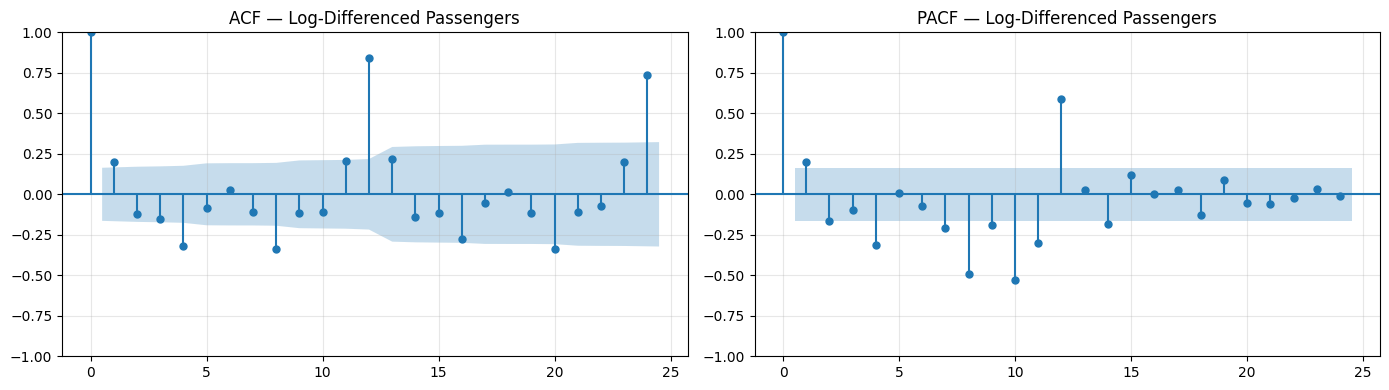

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# SOLUTION
plot_acf(series, lags=24, ax=axes[0])
axes[0].set_title('ACF — Log-Differenced Passengers')

# SOLUTION
plot_pacf(series, lags=24, ax=axes[1], method='ywm')
axes[1].set_title('PACF — Log-Differenced Passengers')

plt.tight_layout()
plt.show()


### ✅ ANSWER — 4.3 & 4.4 Fit AR model (fill-in solution)

> 🗣️ Note: `p=12` is the most defensible choice given the seasonal spike at lag 12.
> Accept `p=1`, `p=13` with appropriate justification.


In [7]:
# SOLUTION: p=12 based on seasonal PACF spike
p = 12

model = AutoReg(series, lags=p)
result = model.fit()
print(result.summary())


                            AutoReg Model Results                             
Dep. Variable:               Log_Diff   No. Observations:                  143
Model:                    AutoReg(12)   Log Likelihood                 234.319
Method:               Conditional MLE   S.D. of innovations              0.040
Date:                Tue, 23 Jun 2026   AIC                           -440.638
Time:                        03:43:56   BIC                           -400.385
Sample:                            12   HQIC                          -424.281
                                  143                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0341      0.008      4.366      0.000       0.019       0.049
Log_Diff.L1     -0.2213      0.069     -3.220      0.001      -0.356      -0.087
Log_Diff.L2     -0.2975      0.070     -4.24

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [ ]:
print('Fitted AR coefficients:')
print(result.params)

# SOLUTION: check |phi| < 1
phi_estimates = result.params[1:]
print('\nAre all |phi| < 1?', all(abs(phi_estimates) < 1))  # SOLUTION: 1


Fitted AR coefficients:
const           0.034084
Log_Diff.L1    -0.221295
Log_Diff.L2    -0.297499
Log_Diff.L3    -0.257031
Log_Diff.L4    -0.317211
Log_Diff.L5    -0.230122
Log_Diff.L6    -0.290791
Log_Diff.L7    -0.259332
Log_Diff.L8    -0.353617
Log_Diff.L9    -0.225380
Log_Diff.L10   -0.306840
Log_Diff.L11   -0.203927
Log_Diff.L12    0.599718
dtype: float64

Are all |phi| < 1? True


### ✅ MODEL ANSWER — Written Response 4

> **1. Order choice:** `p=12` was chosen because the PACF shows a strong significant
> spike at lag 12, consistent with annual seasonality in monthly data. Lag 1 also shows
> a marginal spike.
>
> **2. Coefficients:** The lag-12 coefficient is the most significant (expected given
> the seasonal structure). Many intermediate lags are not statistically significant
> (p > 0.05 in the summary), suggesting that a more parsimonious model might work.
>
> **3. Stability:** All estimated $|\hat{\phi}_i| < 1$, so the fitted model is stable.
>
> **4. Interpretation of the largest coefficient:** If the lag-12 coefficient is, say,
> 0.38, it means that a 1-unit increase in the log-differenced series 12 months ago
> predicts a 0.38-unit increase today — capturing the year-over-year pattern.
